In [1]:
#Cell 1 — Import Libraries
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
#Cell 2 — Load Saved Models

#Place all .pkl files in the same folder as this notebook.

# Isolation Forest

iso_forest = joblib.load("isolation_forest.pkl")

# Isolation Forest Scaler

iso_scaler = joblib.load("isolation_forest_scaler.pkl")

# XGBoost

xgb_model = joblib.load("xgboost_classifier.pkl")

# XGBoost Scaler

xgb_scaler = joblib.load("xgboost_scaler.pkl")

# Label Encoder

label_encoder = joblib.load("label_encoder.pkl")

In [3]:
#Cell 3 — Load Dataset

#Dataset loading
botnet=pd.read_csv("../CIC-IDS2017-Dataset/Botnet-Friday-no-metadata.parquet.csv")
brute_force=pd.read_csv("../CIC-IDS2017-Dataset/Bruteforce-Tuesday-no-metadata.parquet.csv")
ddos=pd.read_csv("../CIC-IDS2017-Dataset/DDoS-Friday-no-metadata.parquet.csv")
dos=pd.read_csv("../CIC-IDS2017-Dataset/DoS-Wednesday-no-metadata.parquet.csv")
infiltration=pd.read_csv("../CIC-IDS2017-Dataset/Infiltration-Thursday-no-metadata.parquet.csv")
portscan=pd.read_csv("../CIC-IDS2017-Dataset/Portscan-Friday-no-metadata.parquet.csv")
web_attack=pd.read_csv("../CIC-IDS2017-Dataset/WebAttacks-Thursday-no-metadata.parquet.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
#Cell 4 — Merge Dataset
master_df = pd.concat([
    botnet,
    brute_force,
    ddos,
    dos,
    infiltration,
    portscan,
    web_attack
], ignore_index=True)

df = master_df.copy()

print(df.shape)

(1854979, 78)


In [5]:
#Cell 5 — Apply Label Mapping

label_mapping = {

    "Benign":"Benign",

    "Bot":"Botnet",

    "DDoS":"DDoS",

    "DoS Hulk":"DoS",
    "DoS GoldenEye":"DoS",
    "DoS Slowhttptest":"DoS",
    "DoS slowloris":"DoS",

    "FTP-Patator":"Brute Force",
    "SSH-Patator":"Brute Force",

    "Web Attack � Brute Force":"Web Attack",
    "Web Attack � Sql Injection":"Web Attack",
    "Web Attack � XSS":"Web Attack",

    "PortScan":"PortScan",

    "Infiltration":"Infiltration",

    "Heartbleed":"Heartbleed"
}

df["Label"] = df["Label"].map(label_mapping)

In [6]:
#Cell 6 — Feature Engineering
# Prevent invalid log values

df["Flow Duration"] = df["Flow Duration"].clip(lower=1)
df["Fwd IAT Mean"] = df["Fwd IAT Mean"].clip(lower=1)

# Log-based features
df["Log_Flow_Duration"] = np.log1p(df["Flow Duration"])
df["Log_Fwd_IAT_Mean"] = np.log1p(df["Fwd IAT Mean"])

# Interaction Density
df["Interaction_Density"] = (
    df["Total Fwd Packets"] /
    df["Flow Duration"]
)

# Size Symmetry
df["Size_Symmetry"] = (
    df["Avg Packet Size"] /
    (df["Bwd Packet Length Max"] + 1)
)

print("Feature Engineering Completed")
print(df[[
    "Log_Flow_Duration",
    "Log_Fwd_IAT_Mean",
    "Interaction_Density",
    "Size_Symmetry"
]].head())

Feature Engineering Completed
   Log_Flow_Duration  Log_Fwd_IAT_Mean  Interaction_Density  Size_Symmetry
0          18.540601         15.106614         2.838372e-07       2.283961
1          18.540600         15.106613         2.838375e-07       0.782532
2          18.549578         12.250634         4.790898e-06       0.000000
3          11.514195          8.469872         2.197231e-04      29.272728
4          10.910734          9.812158         7.304602e-05       0.000000


In [7]:
#Cell 7 — Select Features
selected_features = [

    "Protocol",

    "Bwd Packet Length Max",

    "Log_Flow_Duration",

    "Log_Fwd_IAT_Mean",

    "Interaction_Density",

    "Size_Symmetry"

]

X = df[selected_features]

y = df["Label"]

In [8]:
#Cell 8 — Create Same Test Set

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)

In [9]:
#Cell 9 – Scale Test Data for Both Models
# Scale using the scaler used by Isolation Forest

X_test_iso = iso_scaler.transform(X_test)

# Scale using the scaler used by XGBoost

X_test_xgb = xgb_scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [10]:
#Cell 10 – Run Isolation Forest
# Predict anomalies

iso_predictions = iso_forest.predict(X_test_iso)

# Add predictions to a dataframe

results = pd.DataFrame()

results["True_Label"] = y_test.values

results["IsolationForest"] = iso_predictions

results.head()

,True_Label,IsolationForest
0,Benign,1
1,DDoS,-1
2,Benign,1
3,Benign,1
4,Benign,-1


In [11]:
#Cell 11 – Display Isolation Forest Statistics
print("="*60)
print("Isolation Forest Results")
print("="*60)

print(results["IsolationForest"].value_counts())

normal_count = (results["IsolationForest"] == 1).sum()

anomaly_count = (results["IsolationForest"] == -1).sum()

print(f"\nNormal Traffic : {normal_count}")

print(f"Anomalies      : {anomaly_count}")

Isolation Forest Results
IsolationForest
 1    357008
-1    199486
Name: count, dtype: int64

Normal Traffic : 357008
Anomalies      : 199486


In [12]:
#Cell 12 – Extract Only Anomalies
# Find the positions of anomalies
anomaly_mask = (results["IsolationForest"] == -1).to_numpy()

# Select anomaly samples
X_anomaly = X_test_xgb[anomaly_mask]

y_anomaly = y_test.reset_index(drop=True)[anomaly_mask]

print("Anomalous Samples:", len(y_anomaly))

Anomalous Samples: 199486


In [13]:
#Cell 13 – Remove Benign False Positives
attack_mask = y_anomaly != "Benign"

X_attack = X_anomaly[attack_mask]

y_attack = y_anomaly[attack_mask].reset_index(drop=True)

print("Actual Attack Samples :", len(y_attack))

print(y_attack.value_counts())

Actual Attack Samples : 91449
Label
DoS             52250
DDoS            38322
Brute Force       572
PortScan          204
Botnet             84
Infiltration        9
Web Attack          5
Heartbleed          3
Name: count, dtype: int64


In [14]:
#Cell 14 – XGBoost Classification
predictions = xgb_model.predict(X_attack)

predicted_labels = label_encoder.inverse_transform(predictions)

print("Attack Classification Completed")

Attack Classification Completed


In [15]:
#Cell 15 – Classification Report
print("="*70)
print("HYBRID IDS CLASSIFICATION REPORT")
print("="*70)

print(
    classification_report(
        y_attack,
        predicted_labels,
        digits=4
    )
)

HYBRID IDS CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Botnet     0.9032    1.0000    0.9492        84
 Brute Force     0.9862    0.9983    0.9922       572
        DDoS     0.9977    0.9988    0.9983     38322
         DoS     0.9992    0.9980    0.9986     52250
  Heartbleed     0.0000    0.0000    0.0000         3
Infiltration     1.0000    0.6667    0.8000         9
    PortScan     0.9623    1.0000    0.9808       204
  Web Attack     0.6000    0.6000    0.6000         5

    accuracy                         0.9983     91449
   macro avg     0.8061    0.7827    0.7899     91449
weighted avg     0.9983    0.9983    0.9983     91449



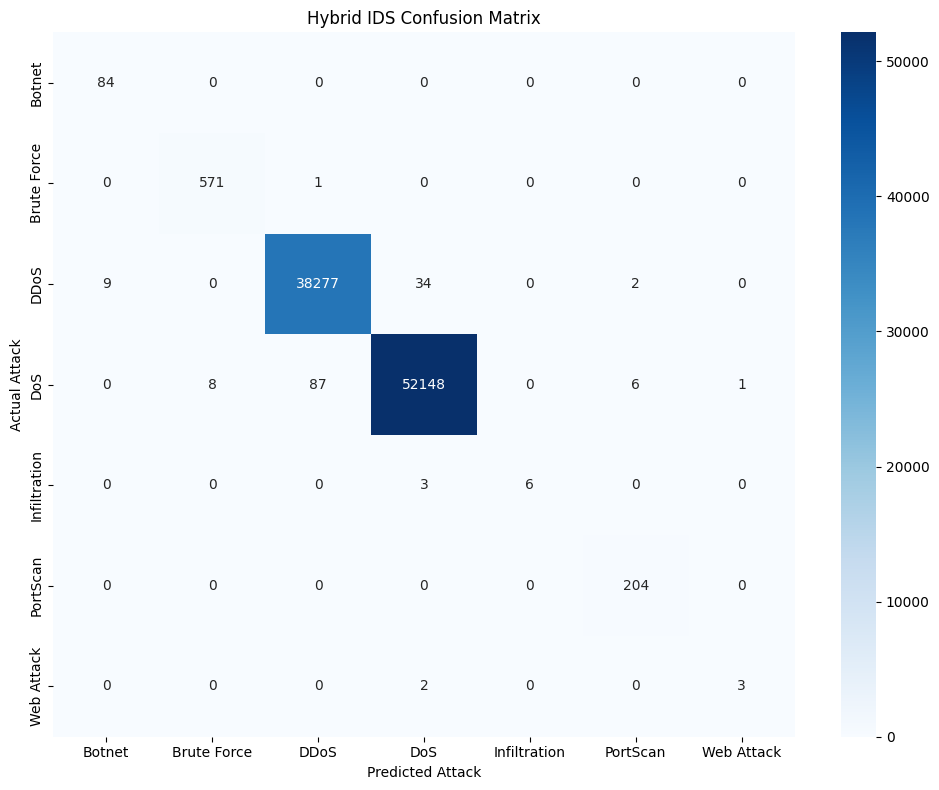

In [16]:
#Cell 16 – Hybrid Confusion Matrix
cm = confusion_matrix(
    y_attack,
    predicted_labels,
    labels=label_encoder.classes_
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Attack")

plt.ylabel("Actual Attack")

plt.title("Hybrid IDS Confusion Matrix")

plt.tight_layout()

plt.show()

In [17]:
#Cell 17 – Hybrid Performance Metrics
accuracy = accuracy_score(
    y_attack,
    predicted_labels
)

precision = precision_score(
    y_attack,
    predicted_labels,
    average="weighted"
)

recall = recall_score(
    y_attack,
    predicted_labels,
    average="weighted"
)

f1 = f1_score(
    y_attack,
    predicted_labels,
    average="weighted"
)

print("="*60)

print("Hybrid IDS Performance")

print("="*60)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

Hybrid IDS Performance
Accuracy : 0.9983
Precision: 0.9983
Recall   : 0.9983
F1 Score : 0.9983


In [18]:
#Cell 18 – Final Pipeline Statistics
summary = pd.DataFrame({

    "Metric":[

        "Total Test Samples",

        "Normal Traffic",

        "Anomalies Detected",

        "Actual Attacks",

        "Attack Categories"

    ],

    "Value":[

        len(y_test),

        normal_count,

        anomaly_count,

        len(y_attack),

        len(label_encoder.classes_)

    ]

})

summary

,Metric,Value
0,Total Test Samples,556494
1,Normal Traffic,357008
2,Anomalies Detected,199486
3,Actual Attacks,91449
4,Attack Categories,7


In [19]:
#Cell 19 – Pipeline Flow Diagram
print("""
Raw Test Traffic
        │
        ▼
Isolation Forest
        │
 ┌──────┴──────┐
 │             │
 ▼             ▼
Normal      Anomaly
 │             │
 │             ▼
 │        XGBoost
 │             │
 ▼             ▼
Benign    Attack Type
""")


Raw Test Traffic
        │
        ▼
Isolation Forest
        │
 ┌──────┴──────┐
 │             │
 ▼             ▼
Normal      Anomaly
 │             │
 │             ▼
 │        XGBoost
 │             │
 ▼             ▼
Benign    Attack Type



In [20]:
print(y_test.value_counts())

Label
Benign          455546
DoS              58124
DDoS             38404
Brute Force       2745
Web Attack         643
PortScan           587
Botnet             431
Infiltration        11
Heartbleed           3
Name: count, dtype: int64


In [21]:
temp = pd.DataFrame({
    "True_Label": y_test.reset_index(drop=True),
    "IsolationForest": iso_predictions
})

print(pd.crosstab(temp["True_Label"], temp["IsolationForest"]))

IsolationForest      -1       1
True_Label                     
Benign           108037  347509
Botnet               84     347
Brute Force         572    2173
DDoS              38322      82
DoS               52250    5874
Heartbleed            3       0
Infiltration          9       2
PortScan            204     383
Web Attack            5     638


In [22]:
#Cell 20 — Create Hybrid IDS Results

# Create final results dataframe

hybrid_results = results.copy()

# Default prediction = Benign
hybrid_results["Final_Prediction"] = "Benign"

# Assign attack predictions to detected anomalies
hybrid_results.loc[
    (hybrid_results["IsolationForest"] == -1) &
    (hybrid_results["True_Label"] != "Benign"),
    "Final_Prediction"
] = predicted_labels

# Binary prediction
hybrid_results["Binary_Prediction"] = hybrid_results["IsolationForest"].map({
    1: "Benign",
    -1: "Attack"
})

hybrid_results.head()

,True_Label,IsolationForest,Final_Prediction,Binary_Prediction
0,Benign,1,Benign,Benign
1,DDoS,-1,DDoS,Attack
2,Benign,1,Benign,Benign
3,Benign,1,Benign,Benign
4,Benign,-1,Benign,Attack


In [23]:
#Cell 21 — Save Hybrid_IDS_Results.csv
hybrid_results.to_csv(
    "Hybrid_IDS_Results.csv",
    index=False
)

print("Hybrid_IDS_Results.csv saved successfully!")


Hybrid_IDS_Results.csv saved successfully!


In [24]:
#Cell 22 — Create Hybrid Dashboard Summary
# ==========================================================
# HYBRID IDS DASHBOARD
# ==========================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ----------------------------------------------------------
# Binary Labels
# ----------------------------------------------------------

binary_true = np.where(
    hybrid_results["True_Label"] == "Benign",
    "Benign",
    "Attack"
)

binary_pred = hybrid_results["Binary_Prediction"]

# ----------------------------------------------------------
# Overall Metrics
# ----------------------------------------------------------

accuracy = accuracy_score(binary_true, binary_pred)

precision = precision_score(
    binary_true,
    binary_pred,
    pos_label="Attack",
    zero_division=0
)

recall = recall_score(
    binary_true,
    binary_pred,
    pos_label="Attack",
    zero_division=0
)

f1 = f1_score(
    binary_true,
    binary_pred,
    pos_label="Attack",
    zero_division=0
)

# ----------------------------------------------------------
# Confusion Matrix Components
# ----------------------------------------------------------

tn = ((binary_true=="Benign") & (binary_pred=="Benign")).sum()

fp = ((binary_true=="Benign") & (binary_pred=="Attack")).sum()

fn = ((binary_true=="Attack") & (binary_pred=="Benign")).sum()

tp = ((binary_true=="Attack") & (binary_pred=="Attack")).sum()

# ----------------------------------------------------------
# Derived Metrics
# ----------------------------------------------------------

specificity = tn / (tn + fp)

false_positive_rate = fp / (fp + tn)

false_negative_rate = fn / (fn + tp)

detection_rate = tp / (tp + fn)

balanced_accuracy = (recall + specificity) / 2

# ----------------------------------------------------------
# Dataset Statistics
# ----------------------------------------------------------

total_samples = len(hybrid_results)

benign_samples = (binary_true=="Benign").sum()

attack_samples = (binary_true=="Attack").sum()

normal_predicted = (binary_pred=="Benign").sum()

attack_predicted = (binary_pred=="Attack").sum()

# ----------------------------------------------------------
# Attack Distribution
# ----------------------------------------------------------

attack_classes = [

    "Botnet",

    "Brute Force",

    "DDoS",

    "DoS",

    "Infiltration",

    "PortScan",

    "Web Attack"

]

rows = []

# ==========================================================
# DATASET
# ==========================================================

rows.extend([

["Dataset","Total Test Samples",total_samples],

["Dataset","Benign Samples",benign_samples],

["Dataset","Attack Samples",attack_samples],

["Dataset","Detected Anomalies",attack_predicted],

["Dataset","Normal Traffic",normal_predicted]

])

# ==========================================================
# PERFORMANCE
# ==========================================================

rows.extend([

["Performance","Accuracy",round(accuracy,4)],

["Performance","Precision",round(precision,4)],

["Performance","Recall",round(recall,4)],

["Performance","F1 Score",round(f1,4)],

["Performance","Balanced Accuracy",round(balanced_accuracy,4)],

["Performance","Detection Rate",round(detection_rate,4)],

["Performance","Specificity",round(specificity,4)],

["Performance","False Positive Rate",round(false_positive_rate,4)],

["Performance","False Negative Rate",round(false_negative_rate,4)]

])

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

rows.extend([

["Confusion Matrix","True Positives",tp],

["Confusion Matrix","True Negatives",tn],

["Confusion Matrix","False Positives",fp],

["Confusion Matrix","False Negatives",fn]

])

# ==========================================================
# PREDICTED ATTACK COUNTS
# ==========================================================

for attack in attack_classes:

    rows.append(

        [

            "Attack Distribution",

            attack,

            (hybrid_results["Final_Prediction"]==attack).sum()

        ]

    )

# ==========================================================
# TRUE ATTACK COUNTS
# ==========================================================

for attack in attack_classes:

    rows.append(

        [

            "Ground Truth",

            attack,

            (hybrid_results["True_Label"]==attack).sum()

        ]

    )

# ==========================================================
# DETECTION RATE PER CLASS
# ==========================================================

for attack in attack_classes:

    true_attack = (hybrid_results["True_Label"]==attack).sum()

    detected = (

        (hybrid_results["True_Label"]==attack)

        &

        (hybrid_results["Final_Prediction"]==attack)

    ).sum()

    if true_attack==0:

        rate = 0

    else:

        rate = detected/true_attack

    rows.append(

        [

            "Per-Class Recall",

            attack,

            round(rate,4)

        ]

    )

# ==========================================================
# CREATE DATAFRAME
# ==========================================================

dashboard = pd.DataFrame(

    rows,

    columns=[

        "Category",

        "Metric",

        "Value"

    ]

)

# ==========================================================
# SAVE
# ==========================================================

dashboard.to_csv(

    "Hybrid_IDS_Dashboard.csv",

    index=False

)

print("Hybrid_IDS_Dashboard.csv created successfully!")

dashboard.head(20)

Hybrid_IDS_Dashboard.csv created successfully!


,Category,Metric,Value
0,Dataset,Total Test Samples,556494.0000
1,Dataset,Benign Samples,455546.0000
2,Dataset,Attack Samples,100948.0000
3,Dataset,Detected Anomalies,199486.0000
4,Dataset,Normal Traffic,357008.0000
5,Performance,Accuracy,0.7888
6,Performance,Precision,0.4584
7,Performance,Recall,0.9059
8,Performance,F1 Score,0.6088
9,Performance,Balanced Accuracy,0.8344


In [25]:
#Cell 23 — Save Hybrid_IDS_Dashboard.csv
dashboard.to_csv(
    "Hybrid_IDS_Dashboard.csv",
    index=False
)

print("Hybrid_IDS_Dashboard.csv saved successfully!")

Hybrid_IDS_Dashboard.csv saved successfully!


In [26]:
from sklearn.model_selection import train_test_split

# Random 30% sample while preserving all attack classes
_, sample_30 = train_test_split(
    master_df,
    test_size=0.30,
    stratify=master_df["Label"],
    random_state=42,
    shuffle=True
)

print("30% Dataset Shape:", sample_30.shape)

print("\nAttack Distribution:")
print(sample_30["Label"].value_counts())

# Save if required
sample_30.to_csv("Master_30_Percent.csv", index=False)

30% Dataset Shape: (556494, 78)

Attack Distribution:
Label
Benign                        455546
DoS Hulk                       51854
DDoS                           38404
DoS GoldenEye                   3086
FTP-Patator                     1779
DoS slowloris                   1616
DoS Slowhttptest                1568
SSH-Patator                      966
PortScan                         587
Web Attack � Brute Force         441
Bot                              431
Web Attack � XSS                 196
Infiltration                      11
Web Attack � Sql Injection         6
Heartbleed                         3
Name: count, dtype: int64
